# 沪深300 三因子研究：可执行教学入口

> 本 Notebook 运行**确定性教学夹具**（固定种子生成的模拟数据），用于验证研究逻辑、失败实验和 REG。它不是沪深 300 真实市场证据。

**学习路径**：理解因子 → 跟做研究 → 回测陷阱 → 可信度六问 → 动手实践（本 Notebook）



## 你将在这个 Notebook 中完成

1. 加载教学夹具数据
2. 查看因子 IC 和分组收益
3. 对比正确做法与四个失败实验
4. 运行 REG 双层判断

**预计时间**：15 分钟 · **需要 Token**：不需要

## 1. 加载教学夹具

教学夹具使用固定种子 `20260901` 生成 60 个月、40 只虚构证券的模拟数据。
它包含三个因子（价值、动量、低波动）和未来收益标签。

运行下面的单元格，你会得到一个包含所有计算结果的字典。

In [1]:
from quant_onboarding.teaching import evaluate_teaching_case

result = evaluate_teaching_case()

# 查看摘要
print("教学夹具 (fixture) 已加载")
print(f"教学月份: {result["summary"]["months"]}")
print(f"虚构证券数: {result["summary"]["assets"]}")
print(f"月均 IC: {result["summary"]["mean_ic"]:.4f}")
print(f"ICIR: {result["summary"]["icir"]:.4f}")
print(f"教学组合年化收益: {result["summary"]["annual_return"]:.2%}")
print(f"最大回撤: {result["summary"]["max_drawdown"]:.2%}")
print(f"月均换手: {result["summary"]["average_turnover"]:.2%}")

教学夹具 (fixture) 已加载
教学月份: 60
虚构证券数: 40
月均 IC: 0.1380
ICIR: 1.0116
教学组合年化收益: 7.23%
最大回撤: -1.84%
月均换手: 36.88%


## 2. 因子证据：IC 与分组收益

IC（信息系数）衡量因子排名与未来收益排名的相关性。正 IC 意味着高分股票未来收益倾向于更高。

分组收益将股票按因子分数分为 5 组，观察最高组与最低组的收益差异。
如果因子有效，高分组收益应持续高于低分组。

In [2]:
print('=== 月度 IC 统计 ===')
print(f"有效月度 IC 数: {int(result['ic'].notna().sum())}")
print(f"月均 IC: {round(float(result['ic'].mean()), 4)}")
print(f"IC 标准差: {round(float(result['ic'].std()), 4)}")
print(f"ICIR: {round(float(result['ic'].mean() / result['ic'].std(ddof=1)), 4)}")
print(f"正 IC 比例: {round(float((result['ic'] > 0).mean()), 2)}")

print('\n=== 五组平均收益（1=最低分，5=最高分）===')
result['group_returns'].rename('mean_forward_return').to_frame()

=== 月度 IC 统计 ===
有效月度 IC 数: 60
月均 IC: 0.138
IC 标准差: 0.1364
ICIR: 1.0116
正 IC 比例: 0.82

=== 五组平均收益（1=最低分，5=最高分）===


,mean_forward_return
group,
1,-0.006163
2,-0.004331
3,-0.000370
4,0.003113
5,0.006632


## 3. 正确做法 vs 四个失败实验

每个实验只改变一个条件，其余与正确管线完全一致：

| 实验 | 唯一改变 | 预期后果 |
|---|---|---|
| **Correct** | 无 | 基准结果 |
| **E1 未来数据** | 用未来收益打分 | 收益虚高，研究无效 |
| **E2 幸存者偏差** | 只保留历史表现好的股票 | 遗漏失败者，高估收益 |
| **E3 忽略成本** | 成本设为 0 | 收益虚高，策略不可交易 |
| **E4 确认污染** | 全周期选最优因子 | 把试错包装成验证 |

下面画出六条累计曲线（正确 + 四个失败 + 基准）。

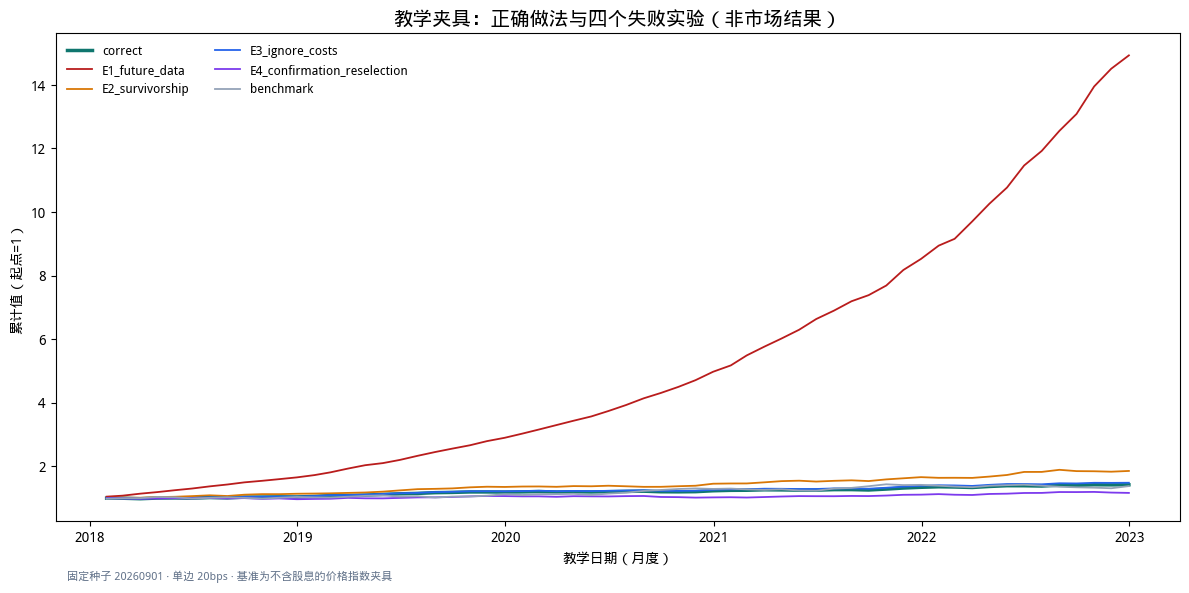


=== 各实验年化收益对比 ===
correct                        +7.31%
E1_future_data                 +71.80%
E2_survivorship                +13.30%
E3_ignore_costs                +8.26%
E4_confirmation_reselection    +3.14%


In [3]:
import matplotlib.pyplot as plt
import pandas as pd

# 计算累计收益
wealth = pd.DataFrame({
    name: (1 + series.fillna(0)).cumprod()
    for name, series in result['returns'].items()
})

# 绘图
colors = {
    'correct': '#0f766e',
    'E1_future_data': '#b91c1c',
    'E2_survivorship': '#d97706',
    'E3_ignore_costs': '#2563eb',
    'E4_confirmation_reselection': '#7c3aed',
    'benchmark': '#94a3b8',
}

# Ensure fonts work on systems without Chinese fonts
plt.rcParams["svg.fonttype"] = "none"
try:
    plt.rcParams["font.sans-serif"] = ["WenQuanYi Micro Hei", "DejaVu Sans"]
except Exception:
    plt.rcParams["font.sans-serif"] = ["DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False

fig, ax = plt.subplots(figsize=(12, 6))
for name, series in wealth.items():
    ax.plot(series.index, series.values, label=name,
            color=colors.get(name, '#999'),
            linewidth=2.5 if name == 'correct' else 1.3)

ax.set_title('教学夹具：正确做法与四个失败实验（非市场结果）', fontsize=14)
ax.set_xlabel('教学日期（月度）')
ax.set_ylabel('累计值（起点=1）')
ax.legend(ncol=2, frameon=False, fontsize=9)
ax.text(0.01, -0.12, '固定种子 20260901 · 单边 20bps · 基准为不含股息的价格指数夹具',
        transform=ax.transAxes, fontsize=8, color='#64748b')
fig.tight_layout()
plt.show()

# 数值对比
print('\n=== 各实验年化收益对比 ===')
for name in ['correct', 'E1_future_data', 'E2_survivorship', 
             'E3_ignore_costs', 'E4_confirmation_reselection']:
    s = result['returns'][name]
    ann = (1 + s.mean())**12 - 1
    print(f"{name:30s} {ann:+.2%}")

## 4. REG 双层结论

**第一层（D/T/P）**：数据、时序、复现 → 决定研究是否有效。
**第二层（S/C/R）**：统计、成本、稳健性 → 决定策略是否推进。

教学夹具的 REG 应该全绿（因为它是"设计好的"完美数据）。
真实案例中 C 和 R 门未通过，导致 credible_stop。

In [4]:
print('=== REG 双层结论 ===')
print(f"研究有效性: {result['reg']['research_validity']}")
print(f"策略推进: {result['reg']['strategy_action']}")

print('\n=== 六道门状态 ===')
gates_df = pd.DataFrame(result['reg']['gates'])
gates_df[['code', 'name', 'status', 'evidence']]

=== REG 双层结论 ===
研究有效性: 有效：D/T/P 无红灯
策略推进: 继续：进入下一阶段评审（不代表投资建议）

=== 六道门状态 ===


,code,name,status,evidence
0,D,数据,green,coverage=1.000
1,T,时序,green,time_order_valid=True
2,S,统计,green,ic_observations=60
3,C,成本,green,cost_model_complete=True; net_effect=0.0059
4,R,稳健性,green,robust=True
5,P,复现,green,reproducible=True


## 5. 尝试修改参数

下面是一个可选练习：修改选股比例或成本费率，观察结果如何变化。

推荐修改（任选一个）：
- 将 `top_quantile_weights` 的 `0.2`（Top 20%）改为 `0.1`（Top 10%）
- 将 `cost_bps=20` 改为 `cost_bps=50`

修改后重新运行所有单元格，观察 IC、收益、换手和 REG 的变化。

In [5]:
# === 修改参数实验 ===
# 将下面的 0.2 改为 0.1，或 20 改为 50，然后重新运行所有单元格

from quant_onboarding.teaching import generate_teaching_panel
from quant_onboarding.research import (
    process_cross_section, top_quantile_weights,
    information_coefficient, performance_summary
)
from quant_onboarding.execution import turnover, transaction_cost

panel = generate_teaching_panel()

# ---- 修改这两个参数 ----
TOP_FRACTION = 0.2   # 试试 0.1
COST_BPS = 20        # 试试 50
# ------------------------

returns = {}
prev = None
for date, frame in panel.groupby('trade_date', sort=True):
    processed = process_cross_section(
        frame.set_index('symbol'), ['value', 'momentum', 'low_volatility']
    )
    w = top_quantile_weights(processed['composite'], TOP_FRACTION)
    lab = processed['forward_return']
    g = float((w * lab.fillna(0)).sum())
    t = turnover(pd.Series() if prev is None else prev, w)
    net = g - transaction_cost(t, COST_BPS)
    returns[date] = net
    prev = w

s = pd.Series(returns)
perf = performance_summary(s, 12)
print(f"选股比例: {TOP_FRACTION:.0%}, 成本: {COST_BPS} bps")
print(f"年化收益: {perf.annual_return:.2%}")
print(f"年化波动: {perf.annual_volatility:.2%}")
print(f"最大回撤: {perf.max_drawdown:.2%}")
print(f"月均换手: {float(pd.Series({date: turnover(
    pd.Series() if i==0 else prev, 
    top_quantile_weights(
        process_cross_section(
            frame.set_index('symbol'), 
            ['value','momentum','low_volatility']
        )['composite'], TOP_FRACTION
    )
) for i, (date, frame) in enumerate(panel.groupby('trade_date', sort=True))}).mean()):.2%}")

选股比例: 20%, 成本: 20 bps
年化收益: 7.23%
年化波动: 3.92%
最大回撤: -1.84%


月均换手: 74.17%


## 下一步

- [回测陷阱实验室](../content/failure-lab.html)
- [可信度六问](../content/credibility.html)
- [知识库](../content/glossary.html)
- 使用真实数据：`bash scripts/project.sh probe && bash scripts/project.sh fetch`

本 Notebook 使用确定性教学夹具，不代表真实市场数据或投资建议。